# Predição Longitudinal de Degradação Motora na Doença de Parkinson
## 🧠 Um Estudo de Viabilidade Prospectiva, Custo-Benefício Clínico e Explicabilidade Algorítmica

---

### 1. Contextualização

#### 1.1 Doença de Parkinson e a Escala MDS-UPDRS
A **Doença de Parkinson (DP)** é uma das condições neurodegenerativas mais prevalentes do mundo, caracterizada pela perda progressiva de neurônios dopaminérgicos na *substantia nigra* e pelo acúmulo patológico da proteína alfa-sinucleína. Sua evolução clínica é marcada por uma profunda heterogeneidade interindividual: enquanto alguns pacientes sofrem um declínio funcional acelerado, comprometendo rapidamente sua autonomia, outros apresentam uma progressão lenta ao longo de vários anos. Prever essa trajetória é crucial para a personalização terapêutica e o planejamento do cuidado médico.

Para quantificar a gravidade e a progressão da patologia, a comunidade neurológica adota globalmente a escala **MDS-UPDRS (Unified Parkinson's Disease Rating Scale)**. Para compreender a dinâmica de modelagem deste projeto, é fundamental mapear a estrutura desta métrica:

| Subescala | Nome Oficial | Domínio Principal de Avaliação | Tipo de Coleta / Natureza dos Dados | Relação com a Modelagem Prospectiva |
| :--- | :--- | :--- | :--- | :--- |
| **Parte 1** | Experiências Não-Motoras da Vida Diária | Aspectos cognitivos, humor, comportamento, depressão, ansiedade e distúrbios do sono. | **Subjetivo** (Baseado no auto-relato do paciente ou entrevista clínica) | **Descartado:** Alta variabilidade de percepção individual e ruído psicossocial. |
| **Parte 2** | Experiências Motoras da Vida Diária | Impacto dos sintomas físicos nas atividades cotidianas (fala, escrita, mastigação, vestimenta e higiene). | **Subjetivo** (Questionário estruturado preenchido pelo próprio paciente) | **Descartado:** Depende fortemente do nível de tolerância e suporte do indivíduo. |
| **Parte 3** | Exame Motor | Sinais cardinais da doença: rigidez, tremor de repouso, bradicinesia, instabilidade postural, marcha e fácies. | **Objetivo** (Exame físico padronizado e pontuado diretamente pelo Neurologista) | **Selecionado como Variável Alvo:** Indicador clínico mais objetivo da degradação motora. |
| **Parte 4** | Complicações Motoras | Presença, gravidade e impacto de flutuações motoras (períodos *Off*) e discinesias causados pela medicação. | **Misto** (Mapeia a resposta e os efeitos colaterais da terapia farmacológica) | **Descartado:** É condicionado ao paciente estar utilizando a medicação. |

**Justificativa do Recorte Metodológico:**
As Partes 1 e 2 carregam um viés inerente de subjetividade por dependerem da interpretação do paciente, enquanto a Parte 4 está estritamente condicionada ao tempo de uso de medicações como a Levodopa. A **Parte 3 (Exame Motor)** consolida-se como o único indicador clínico estável, padronizado e universalmente auditável pelo especialista para mensurar a progressão real da neurodegeneração. Por esse motivo, este trabalho isola e foca exclusivamente no escore do **MDS-UPDRS Parte 3** como sua variável alvo quantitativa.

#### 1.2 O Dataset e a Assimetria de Dados Clinico-Moleculares
Os dados utilizados neste estudo provêm da iniciativa **AMP-PD (Accelerated Medicines Partnership Parkinson's Disease)** e apresentam uma característica comum em cenários hospitalares reais: a assimetria na abundância de dados de acordo com o custo de sua coleta. O ecossistema é composto por quatro arquivos principais:

1. **Dados Clínicos Principais (`train_clinical_data.csv`):** Histórico longitudinal de avaliações das subescalas MDS-UPDRS e status da medicação dopaminérgica (`On`/`Off`) de pacientes que também passaram por triagem molecular.
2. **Dados Clínicos Suplementares (`supplemental_clinical_data.csv`):** Uma coorte adicional contendo registros clínicos idênticos aos principais, porém de pacientes que **não realizaram exames moleculares**. Este arquivo será integrado para expandir o poder estatístico do nosso modelo puramente clínico.
3. **Abundância de Proteínas (`train_proteins.csv`):** Expressão em massa de proteínas específicas mensuradas via espectrometria de massas no líquido cefalorraquidiano (LCR) e plasma.
4. **Abundância de Peptídeos (`train_peptides.csv`):** Quantificação dos componentes estruturais das proteínas coletadas.

**Premissa de Isolamento Prospectivo e Assimetria:**
Para mimetizar com precisão o cenário de um consultório médico e eliminar o vazamento de dados futuros, todas as características preditivas laboratoriais e clínicas serão extraídas **exclusivamente no Mês 0 (Baseline)**. 

Essa estrutura nos permite explorar uma realidade prática da saúde pública: o **Modelo A (Puramente Clínico)** se beneficiará da abundância de dados gerada pela fusão das bases principal e suplementar (baixíssimo custo de coleta), enquanto o **Modelo B (Clínico + Proteínas)** ficará restrito à base principal devido à escassez de exames proteômicos de alto custo. Porém, para uma comparação justa, utilizaremos os dados clínicos suplementares apenas após a comparação dos dois modelos.

---
### 2. Pipeline, Objetivo e Hipótese

#### 2.1 O que será feito (Pipeline Metodológico)
O fluxo de desenvolvimento deste projeto segue as seguintes etapas:

1. **Definição do Baseline (Mês 0):** Isolamento das características iniciais de cada paciente, mapeando seu escore motor de partida (`updrs_3_baseline`) e sua assinatura molecular primária (proteínas/peptídeos coletados na primeira consulta).
2. **Criação da Matriz Longitudinal:** Cruzamento do retrato fixo do Mês 0 com todas as visitas futuras do paciente em instantes de tempo discretos ($t > 0$).
3. **Engenharia de Cenários Farmacológicos:** Inclusão do mês de projeção futura desejado (`visit_month`) e do status simulado da terapia dopaminérgica (`medication_on` em estado ON ou OFF) como preditores dinâmicos.
4. **Validação Cruzada Robusta por Grupo (`GroupKFold`):** Divisão dos dados garantindo que um mesmo paciente nunca pertença simultaneamente aos conjuntos de treino e teste. A avaliação será feita estritamente sobre pacientes inéditos para o algoritmo.
5. **Modelagem de Regressão e Auditoria:** Treinamento do modelo e desconstrução matemática das decisões locais via valores SHAP.

#### 2.2 Objetivos do Trabalho
O objetivo geral deste estudo é desenvolver e auditar um sistema de suporte à decisão clínica capaz de projetar a trajetória de degradação motora individualizada de pacientes com Parkinson sob diferentes cenários de introdução farmacológica.

Os objetivos específicos compreendem:
* **Determinar o real custo-benefício** da inclusão de marcadores proteômicos de alto custo coletados no baseline para a previsão de longo prazo em comparação com um modelo puramente clínico de consultório.
* **Construir um simulador interativo** que permita aos profissionais de saúde estimar o impacto estatístico da introdução precoce ou tardia da medicação dopaminérgica na curva de evolução motora.
* **Garantir a interpretabilidade e auditabilidade** das decisões do modelo de machine learning através de métodos de explicabilidade local, permitindo ao médico compreender quais fatores pesaram para a inclinação da curva prognóstica.

#### 2.3 Hipótese
* **Hipótese Nula ($H_0$):** Não existe diferença estatisticamente significativa na capacidade preditiva entre o modelo de aprendizado de máquina fundamentado exclusivamente no histórico clínico e o modelo enriquecido com dados proteômicos. (O ganho informacional das proteínas para a projeção do UPDRS 3 é nulo).
* **Hipótese Alternativa ($H_1$):** A adição da assinatura proteômica de alta dimensão reduz o erro absoluto do modelo de forma estatisticamente significativa em comparação ao uso isolado de avaliações clínicas basais.

---
### 3. Limpeza e Transformação de Dados

A preparação dos dados neste estudo segue a premissa de um ensaio clínico prospectivo. O objetivo é construir uma "matriz temporal", onde as características completas do paciente no dia do diagnóstico (Mês 0) serão utilizadas como preditoras para a sua condição exclusivamente motora (UPDRS Parte 3) em meses futuros.

#### 3.1 Fusão de Coortes e Rastreabilidade (A Vantagem da Escalabilidade)
Para viabilizar as fases de teste de hipótese e otimização do modelo, integraremos a base clínica principal com a base suplementar. Para manter o rigor científico, criaremos um identificador de origem (`source`). Isso nos permitirá:
1. Realizar um **teste pareado justo** entre dados clínicos e proteômicos usando apenas a base principal.
2. Demonstrar a **escalabilidade** da abordagem clínica, injetando a base suplementar na etapa de otimização final.

#### 3.2 O Tratamento de Nulos (O Caso do UPDRS 4)
Embora nosso alvo de predição seja exclusivamente a Parte 3, as pontuações das Partes 1, 2 e 4 no Baseline (Mês 0) carregam correlações clínicas fundamentais (ex: dificuldades motoras diárias relatadas na Parte 2 são fortes preditoras da rigidez médica na Parte 3). 
Para a Parte 4 (Complicações Motoras), a ausência de registro não indica falha de coleta, mas sim que possivelmente o paciente ainda não desenvolveu discinesias pelo uso de medicação, ou que o paciente não está em tratamento medicamentoso. Portanto, aplicamos a imputação de valor zero (0) para esses casos ausentes.

#### 3.3 Isolamento do Baseline (Mês 0) e Matriz Longitudinal
A transformação estrutural separa os dados em duas dimensões:
* **Baseline (Preditor):** O retrato completo do paciente no Mês 0, contendo suas notas iniciais (`updrs_1`, `updrs_2`, `updrs_3`, `updrs_4`) e a sua assinatura proteômica.
* **Target (Alvo):** A trajetória puramente motora no futuro ($t > 0$), contendo o mês da consulta e o escore do `updrs_3`.

In [74]:
%pip install --quiet lightgbm pandas numpy matplotlib plotly shap seaborn

Note: you may need to restart the kernel to use updated packages.


In [75]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("1. Carregando as bases de dados...")
clin_main = pd.read_csv('train_clinical_data.csv')
clin_supp = pd.read_csv('supplemental_clinical_data.csv')

# Adicionando flag de rastreabilidade
clin_main['source'] = 'main'
clin_supp['source'] = 'supp'

# Unindo os dados clínicos
clin_full = pd.concat([clin_main, clin_supp], ignore_index=True)

# Removendo registros sem o UPDRS 3 (nosso núcleo do projeto)
clin_full = clin_full.dropna(subset=['updrs_3']).copy()

# Binarizando medicação
clin_full['medication_on'] = clin_full['upd23b_clinical_state_on_medication'].apply(lambda x: 1 if x == 'On' else 0)

# Imputação: Na ausência de anotação de complicações, assume-se 0
clin_full['updrs_4'] = clin_full['updrs_4'].fillna(0)

# ==================================================
# EXTRAÇÃO DO BASELINE (MÊS 0) COM TODAS AS FEATURES
# ==================================================
print("\n2. Isolando o Baseline Clínico (Mês 0)...")
cols_baseline = ['patient_id', 'updrs_1', 'updrs_2', 'updrs_3', 'updrs_4', 'source']
baseline_clin = clin_full[clin_full['visit_month'] == 0][cols_baseline].drop_duplicates('patient_id')

# Renomeando para deixar claro que são as notas de partida (Features)
baseline_clin = baseline_clin.rename(columns={
    'updrs_1': 'updrs_1_baseline',
    'updrs_2': 'updrs_2_baseline',
    'updrs_3': 'updrs_3_baseline',
    'updrs_4': 'updrs_4_baseline'
})

# Preenchendo raros nulos de updrs 1 e 2 no baseline com a mediana daquele mês
for col in ['updrs_1_baseline', 'updrs_2_baseline']:
    baseline_clin[col] = baseline_clin[col].fillna(baseline_clin[col].median())

print("3. Processando a Proteômica do Baseline...")
prot = pd.read_csv('train_proteins.csv')
prot_m0 = prot[prot['visit_month'] == 0].copy()

# Selecionando as 100 proteínas mais abundantes
top_proteins = prot_m0.groupby('UniProt')['NPX'].mean().sort_values(ascending=False).head(100).index
prot_m0_filtered = prot_m0[prot_m0['UniProt'].isin(top_proteins)]

baseline_prot = prot_m0_filtered.pivot(index='patient_id', columns='UniProt', values='NPX').reset_index()

# Unindo Clínico e Proteínas no Baseline
baseline_completo = pd.merge(baseline_clin, baseline_prot, on='patient_id', how='left')

# ==========================================
# CONSTRUÇÃO DA MATRIZ LONGITUDINAL ALVO
# ==========================================
print("\n4. Construindo a Matriz Temporal...")
# O Alvo de predição futuro é ESTRITAMENTE o updrs_3
target_df = clin_full[clin_full['visit_month'] > 0][['patient_id', 'visit_month', 'medication_on', 'updrs_3']].copy()

# Cruzando o Target com o Baseline
df_model = pd.merge(target_df, baseline_completo, on='patient_id', how='inner')

print("\n--- RESUMO DO DATASET FINAL ---")
print(f"Total de predições futuras possíveis: {len(df_model)}")
print(f"Features clínicas capturadas no Baseline: UPDRS 1, 2, 3 e 4")
print(f"Alvo (Target) no futuro: Apenas UPDRS 3")

features_proteomicas = list(top_proteins)

1. Carregando as bases de dados...

2. Isolando o Baseline Clínico (Mês 0)...
3. Processando a Proteômica do Baseline...

4. Construindo a Matriz Temporal...

--- RESUMO DO DATASET FINAL ---
Total de predições futuras possíveis: 3791
Features clínicas capturadas no Baseline: UPDRS 1, 2, 3 e 4
Alvo (Target) no futuro: Apenas UPDRS 3


---
### 4. Análise Exploratória de Dados (EDA)

A compreensão visual da progressão natural da Doença de Parkinson e de como as variáveis clínicas interagem é fundamental para validar as premissas da nossa modelagem prospectiva. Nesta seção, utilizamos o dataset longitudinal gerado para investigar as trajetórias motoras e os vieses observacionais da terapia farmacológica.

#### 4.1 Evolução Média do Comprometimento Motor (MDS-UPDRS 3)
A característica central das doenças neurodegenerativas é o declínio funcional contínuo. Ao plotarmos a média da pontuação motora (Parte 3) ao longo dos meses de acompanhamento, esperamos observar uma curva de inclinação positiva (aumento da pontuação = piora clínica), validando a necessidade de modelos que consigam interpolar essa trajetória.

#### 4.2 O Paradoxo Observacional da Medicação
Uma análise ingênua poderia supor que pacientes sob uso de medicação dopaminérgica (estado `On`) apresentariam notas menores (melhores) no exame motor do que pacientes sem medicação (`Off`). No entanto, em dados observacionais do mundo real, ocorre o inverso: a medicação é prescrita e ajustada justamente para os pacientes que apresentam quadros mais severos. Portanto, visualizaremos esse viés analítico, demonstrando por que o algoritmo precisa de cautela ao interpretar a feature `medication_on`.

#### 4.3 Importância das outras partes do UPDRS
Para justificar a inclusão das Partes 1, 2 e 4 do Baseline como *features* para prever a Parte 3 no futuro, analisaremos a correlação entre as dificuldades motoras do dia a dia auto-relatadas (UPDRS 2 no Mês 0) e a real rigidez clínica medida pelo médico anos depois (Mês 24).

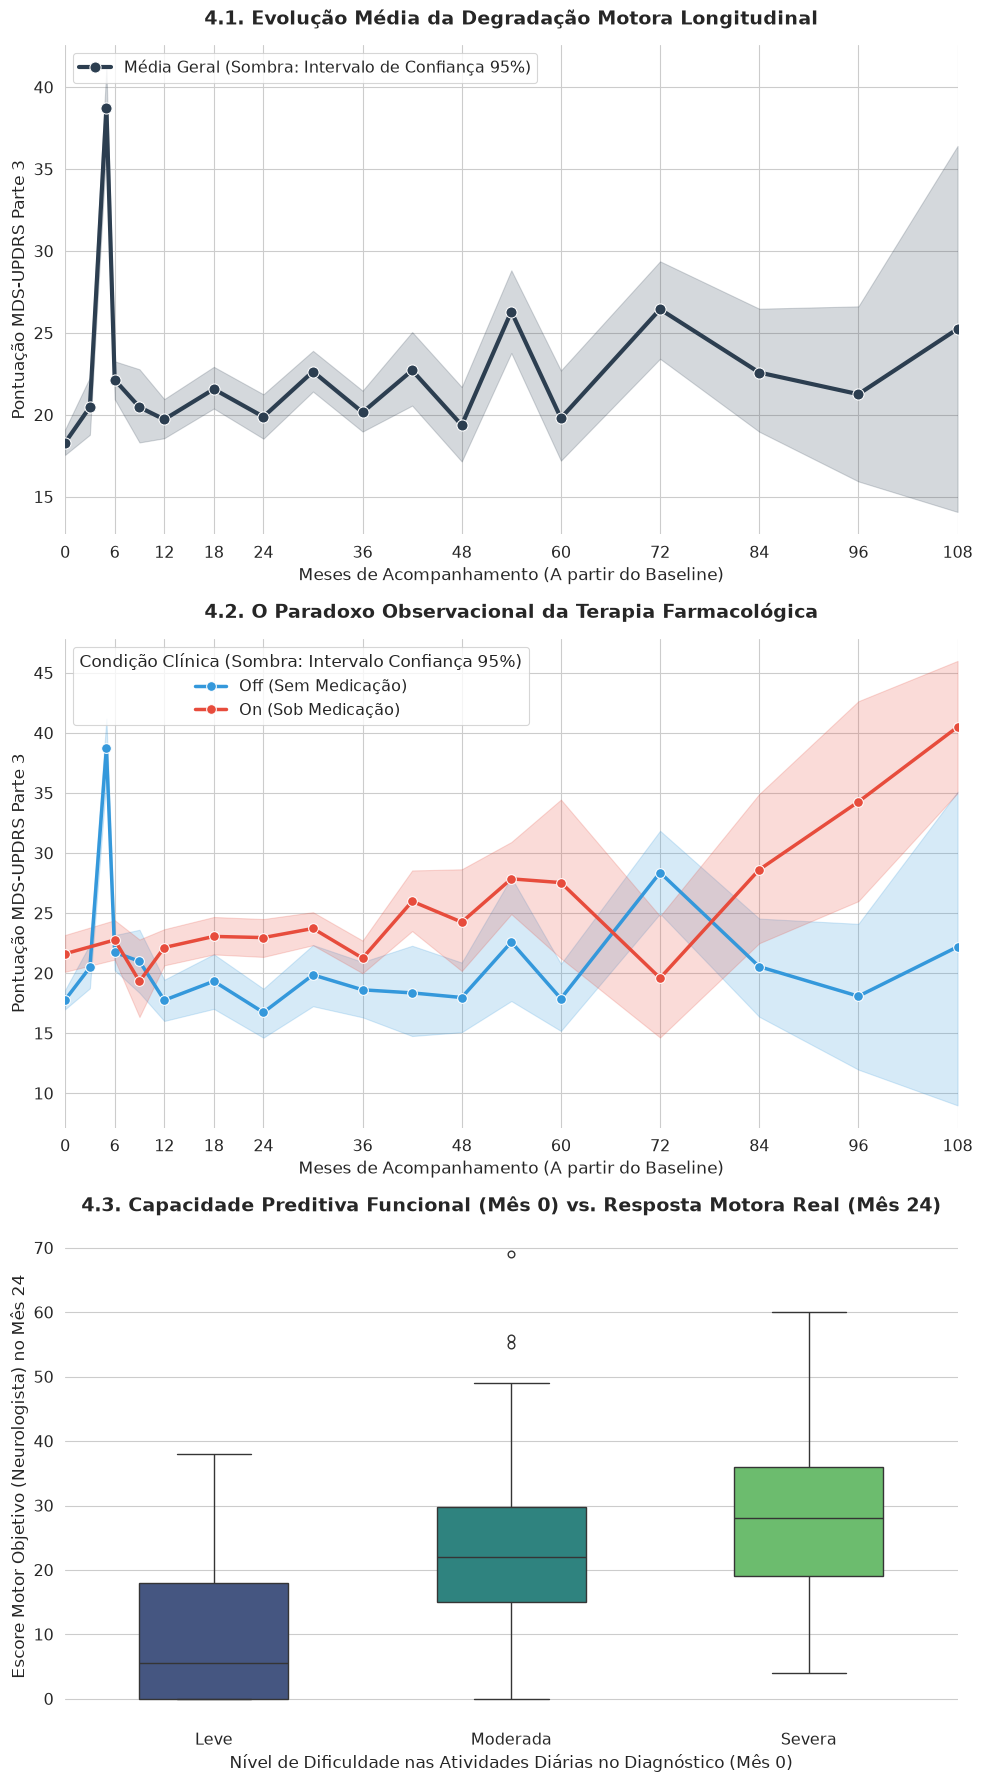

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid", context="paper", font_scale=1.3)

# Usamos clin_full para garantir que o Mês 0 e todas as coortes apareçam
df_plot = clin_full.copy()
df_plot['Status da Medicação'] = df_plot['medication_on'].map({
    0: 'Off (Sem Medicação)',
    1: 'On (Sob Medicação)'
})

# Escala cronológica cobrindo todos os anos do estudo clínico (até o mês 108)
ticks_meses = [0, 6, 12, 18, 24, 36, 48, 60, 72, 84, 96, 108]
mes_maximo = df_plot['visit_month'].max()

# Inicialização da figura
fig, axes = plt.subplots(3, 1, figsize=(10, 18))

# ==========================================
# Gráfico 4.1: Evolução Média Geral
# ==========================================
sns.lineplot(
    data=df_plot,
    x='visit_month',
    y='updrs_3',
    color='#2c3e50',
    linewidth=3,
    marker='o',
    markersize=8,
    label='Média Geral (Sombra: Intervalo de Confiança 95%)',
    ax=axes[0]
)
axes[0].set_title('4.1. Evolução Média da Degradação Motora Longitudinal', fontweight='bold', fontsize=14, pad=15)
axes[0].set_xlabel('Meses de Acompanhamento (A partir do Baseline)', fontsize=12)
axes[0].set_ylabel('Pontuação MDS-UPDRS Parte 3', fontsize=12)
axes[0].set_xlim(0, mes_maximo)
axes[0].set_xticks(ticks_meses)
axes[0].legend(loc='upper left', frameon=True)

# ==========================================
# Gráfico 4.2: O Paradoxo da Medicação
# ==========================================
sns.lineplot(
    data=df_plot,
    x='visit_month',
    y='updrs_3',
    hue='Status da Medicação',
    palette={'Off (Sem Medicação)': '#3498db', 'On (Sob Medicação)': '#e74c3c'},
    linewidth=2.5,
    marker='o',
    markersize=7,
    ax=axes[1]
)
axes[1].set_title('4.2. O Paradoxo Observacional da Terapia Farmacológica', fontweight='bold', fontsize=14, pad=15)
axes[1].set_xlabel('Meses de Acompanhamento (A partir do Baseline)', fontsize=12)
axes[1].set_ylabel('Pontuação MDS-UPDRS Parte 3', fontsize=12)
axes[1].set_xlim(0, mes_maximo)
axes[1].set_xticks(ticks_meses)

axes[1].legend(
    title='Condição Clínica (Sombra: Intervalo Confiança 95%)',
    loc='upper left',
    frameon=True
)

# ==========================================
# Gráfico 4.3: Poder Preditivo das Subescalas
# ==========================================
df_mes_24 = df_model[df_model['visit_month'] == 24].copy()
df_mes_24['Gravidade UPDRS 2 (Baseline)'] = pd.qcut(
    df_mes_24['updrs_2_baseline'],
    q=3,
    labels=['Leve', 'Moderada', 'Severa']
)

sns.boxplot(
    data=df_mes_24,
    x='Gravidade UPDRS 2 (Baseline)',
    y='updrs_3',
    palette='viridis',
    width=0.5,
    ax=axes[2]
)
axes[2].set_title('4.3. Capacidade Preditiva Funcional (Mês 0) vs. Resposta Motora Real (Mês 24)', fontweight='bold', fontsize=14, pad=15)
axes[2].set_xlabel('Nível de Dificuldade nas Atividades Diárias no Diagnóstico (Mês 0)', fontsize=12)
axes[2].set_ylabel('Escore Motor Objetivo (Neurologista) no Mês 24', fontsize=12)

# Ajustes finais
plt.tight_layout()
sns.despine(left=True, bottom=True)
plt.show()

#### 4.4 Interpretação Clínica e Estatística dos Achados Visualizados

A análise visual das dimensões temporais, comportamentais e estatísticas do dataset revela comportamentos críticos que guiarão as decisões de modelagem:

1. **Gráfico 4.1**
    * A curva motora inicia-se no Mês 0, estabelecendo o marco zero do diagnóstico. A macro-tendência clínica aponta para uma progressão contínua da degradação motora (inclinação positiva da linha). A área sombreada ao redor da linha média representa o **Intervalo de Confiança de 95% (IC 95%)**. O fato de a sombra começar  estreita e se alargar significativamente nos anos avançados (especialmente após o Mês 24 e estendendo-se até o Mês 108) traduz graficamente a **profunda heterogeneidade interindividual da Doença de Parkinson** (com o passar do tempo, os pacientes divergem em velocidades de declínio muito distintas) associada ao **atrito amostral** (a redução natural do número de pacientes que permanecem ativos nos anos finais do estudo, o que diminui o volume de dados e faz a incerteza estatística disparar).
   * **O Efeito Zigue-Zague:** Paralelamente, observa-se um padrão oscilatório com picos agudos em meses intermediários (como o Mês 6 e o Mês 18). Este fenômeno é o reflexo estatístico do **Viés de Seleção Hospitalar**. O protocolo padrão convoca toda a coorte em intervalos anuais (diluindo a média com pacientes estáveis). Consultas em meses quebrados ocorrem majoritariamente quando o paciente sofre um declínio clínico agudo que força o neurologista a antecipar o retorno médico. Logo, o pico visível no mês 5 representa uma amostra isolada e temporariamente restrita aos casos mais severos.

2. **Gráfico 4.2:**
   * **Inversão Causal:** Pacientes avaliados sob o efeito da medicação (`On - Linha Vermelha`) apresentam, geralmente, pontuações motoras piores do que os pacientes sem medicação (`Off - Linha Azul`). Em dados observacionais, o neurologista recorre à terapia dopaminérgica especificamente para indivíduos com quadros mais avançados. O algoritmo interpretará a variável `medication_on` como uma forte *proxy* de alta severidade clínica, exigindo cautela na construção do simulador médico prospectivo.

3. **Gráfico 4.3:**
   * Os pacientes que reportaram graus de dificuldade "Severa" nas atividades diárias (MDS-UPDRS Parte 2) no **Mês 0** chegaram no **Mês 24** com as maiores distribuições de rigidez e tremores medidos objetivamente pelo neurologista na Parte 3. Há uma clara separação nas medianas e quartis entre as categorias 'Leve', 'Moderada' e 'Severa'. Isso fornece uma prova estatística de que o auto-relato funcional inicial do paciente não é um ruído descartável, mas sim um forte previsor prospectivo do declínio motor físico de longo prazo, validando o resgate dessas variáveis para compor o vetor de entrada do modelo.

---
### 5. Engenharia de Features e Prevenção de Vieses

#### 5.1 O Descarte do Vazamento de Dados (Data Leakage)
Em competições abertas, algoritmos de alta pontuação frequentemente utilizam variáveis comportamentais que invertem a causalidade, como `visit_6m` (se o paciente retornou ao hospital no 6º mês) ou `blood_taken`. O retorno em meses atípicos atua como uma *proxy* de urgência/gravidade. Se o modelo aprender que "retornar no mês 6 significa piora grave", ele torna-se inútil no Dia 0 do consultório, pois o médico não sabe se o paciente precisará de uma consulta de urgência no futuro. **Todas as variáveis que dependem de eventos futuros não programados foram estritamente descartadas.**

#### 5.2 Expansão Dimensional: Interações e Proxies Clínicos
Para compensar a exclusão das variáveis de vazamento e fornecer um sinal mais forte ao modelo de aprendizado de máquina, aplicamos engenharia de derivadas cruzadas sobre as métricas basais. Algoritmos baseados em árvores possuem alta eficiência em particionamento ortogonal, mas beneficiam imensamente do pré-cálculo de interações não-lineares. Foram introduzidas as seguintes *features* derivadas:

1. **Carga Total Basal (`updrs_total_baseline`):** A soma das quatro partes do MDS-UPDRS no diagnóstico. Captura a gravidade sistêmica inicial do paciente (motora, cognitiva e funcional combinadas).
2. **Razão Motor-Funcional (`motor_adl_ratio`):** A divisão entre o escore motor (Parte 3) e o impacto nas atividades diárias (Parte 2). Pacientes com alto tremor motriz, mas baixo impacto funcional, possuem fenótipos de progressão distintos daqueles com perda funcional severa imediata (que indica instabilidade axial grave).
3. **Razão Motor-Cognitivo (`motor_cog_ratio`):** O declínio cognitivo basal agudo (Parte 1) associado à disfunção motora costuma ser um preditor de progressão agressiva da doença.
4. **Interação Temporal Esperada (`baseline_time_interaction`):** O produto cruzado da severidade motora inicial e do horizonte de tempo. Fornece ao modelo um vetor matemático direto indicando que "altas pontuações basais projetadas para um longo período de tempo" devem resultar nos maiores deltas de degradação.

#### 5.3 Filtragem da Coorte (Correção de Viés de Amostragem)
Conforme identificado na Análise Exploratória, os meses fracionados (como 3, 6, 9 e 18) concentram pacientes que necessitaram de intervenções de urgência, gerando picos artificiais na curva de progressão média populacional. Para garantir que o modelo aprenda a fisiologia longitudinal do Parkinson, o conjunto de treinamento será filtrado para reter estritamente as visitas do protocolo anual oficial (múltiplos de 12), isolando o algoritmo do viés de seleção.

In [77]:
print("5. Executando Engenharia de Features Avançada...\n")

# ==============================================
# 5.1 Criação de Derivadas e Interações Clínicas
# ==============================================
# Carga Total da Doença no momento do diagnóstico
df_model['updrs_total_baseline'] = (
    df_model['updrs_1_baseline'] +
    df_model['updrs_2_baseline'] +
    df_model['updrs_3_baseline'] +
    df_model['updrs_4_baseline']
)

# Razão Motor-Funcional (Adicionamos +1 no denominador para evitar divisão por zero)
df_model['motor_adl_ratio'] = df_model['updrs_3_baseline'] / (df_model['updrs_2_baseline'] + 1.0)

# Razão Motor-Cognitivo
df_model['motor_cog_ratio'] = df_model['updrs_3_baseline'] / (df_model['updrs_1_baseline'] + 1.0)

# Interação cruzada entre gravidade inicial e o tempo futuro a ser projetado
df_model['baseline_time_interaction'] = df_model['updrs_3_baseline'] * df_model['visit_month']

# ==========================================
# 5.2 Definição dos Vetores de Treinamento
# ==========================================
# Vetor Clínico expandido
features_clinicas = [
    'visit_month',
    'medication_on',
    'updrs_1_baseline',
    'updrs_2_baseline',
    'updrs_3_baseline',
    'updrs_4_baseline',
    'updrs_total_baseline',         # Nova feature
    'motor_adl_ratio',              # Nova feature
    'motor_cog_ratio',              # Nova feature
    'baseline_time_interaction'     # Nova feature
]

# A Variável Alvo é universal
target = 'updrs_3'

print(f"-> Dimensão do Vetor Clínico Expandido: {len(features_clinicas)} variáveis operacionais")

# ===========================================================
# 5.3 Filtragem de Protocolo (Remoção do Viés de Zigue-Zague)
# ===========================================================
meses_oficiais = [12, 24, 36, 48, 60, 72, 84, 96, 108]

df_model_clean = df_model[df_model['visit_month'].isin(meses_oficiais)].copy()

print(f"-> Total de registros antes da filtragem: {len(df_model)}")
print(f"-> Total de registros retidos no protocolo anual: {len(df_model_clean)}")

# ==========================================
# 5.4 Verificação de Integridade Matemática
# ==========================================
nulos_clinicos = df_model_clean[features_clinicas].isnull().sum()

if nulos_clinicos.sum() == 0:
    print("\nSucesso: Zero valores nulos na matriz de features expandida.")
else:
    print("\nValores nulos detectados:")
    print(nulos_clinicos[nulos_clinicos > 0])

print(f"Pronto para a Modelagem. Dimensão final da matriz: {df_model_clean.shape}")

5. Executando Engenharia de Features Avançada...

-> Dimensão do Vetor Clínico Expandido: 10 variáveis operacionais
-> Total de registros antes da filtragem: 3791
-> Total de registros retidos no protocolo anual: 2003

Sucesso: Zero valores nulos na matriz de features expandida.
Pronto para a Modelagem. Dimensão final da matriz: (2003, 113)


### 6. Modelagem e Estratégia de Validação

A modelagem preditiva em dados de saúde longitudinais exige salvaguardas rigorosas contra o sobreajuste (*overfitting*) e o vazamento de dados (*data leakage*). O objetivo desta secção é definir o algoritmo de aprendizagem e a estratégia de validação que garantirão que as estimativas de erro do nosso "Gêmeo Digital" sejam honestas e reprodutíveis no mundo real.

#### 6.1 A Escolha do Algoritmo: LightGBM
Para o núcleo preditivo, optámos pelo **LightGBM (Light Gradient Boosting Machine)**. A escolha de um comitê de árvores de decisão baseia-se em três pilares técnicos:
1. **Lidar com Não-Linearidade:** A degradação motora no Parkinson não obedece a uma reta perfeita; o modelo precisa de aprender platôs (ex: fases estabilizadas por medicação) e quedas abruptas.
2. **Robustez a Dados Ausentes:** O algoritmo lida nativamente com a ausência de dados, o que é uma constante em bases de dados hospitalares reais.
3. **Imunidade à Escala:** Ao contrário de redes neurais ou regressões lineares, o LightGBM não exige que as variáveis clínicas (que variam de 0 a 100) e as proteínas (que variam em milhões de NPX) sejam normalizadas, preservando a distribuição original dos dados.

Para forçar a parcimónia e evitar que o algoritmo decore ruídos estatísticos (especialmente as centenas de variáveis proteómicas), configuraremos a arquitetura com uma profundidade rasa (`max_depth=5`) e um número conservador de folhas (`num_leaves=15`).

#### 6.2 Estratégia de Validação Robusta: GroupKFold
A validação cruzada tradicional (*K-Fold* aleatório) é letal em conjuntos de dados longitudinais. Se as medições do Mês 12 de um paciente caírem no conjunto de treino e as medições do Mês 24 do mesmo paciente caírem no conjunto de teste, o modelo não estará a aprender sobre a doença, mas sim a "decorar" o comportamento daquele paciente.
Para garantir um teste cego real e avaliar a capacidade de generalização do modelo, utilizaremos o **GroupKFold**, agrupando pelo `patient_id`. Esta técnica garante que todas as visitas longitudinais de um indivíduo específico fiquem contidas na mesma dobra (*fold*). Como resultado, o modelo será avaliado estritamente em **pacientes inéditos**, mimetizando com precisão o cenário de um novo indivíduo a entrar pela primeira vez no consultório.

In [78]:
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
import warnings
import lightgbm as lgb
import numpy as np
warnings.filterwarnings('ignore')

print("6. Configurando a Máquina de Modelagem e Validação...\n")

# ==========================================
# 6.1 Definição da Métrica Oficial (SMAPE)
# ==========================================
def calcular_smape(y_true, y_pred):
    """
    Calcula o SMAPE (Symmetric Mean Absolute Percentage Error) + 1.
    Adicionamos +1 no denominador para replicar a métrica da competição AMP-PD
    e evitar divisão por zero quando o target real e predito são muito baixos.
    """
    smapes = 200 * np.abs(y_pred - y_true) / (np.abs(y_pred) + np.abs(y_true) + 1)
    return np.mean(smapes)

# ==========================================
# 6.2 O Motor de Treinamento (GroupKFold)
# ==========================================
def motor_de_treino_cv(df_treino, features, target, nome_modelo):
    """
    Motor central que executa a validação cruzada garantindo que
    nenhum paciente 'vaze' do treino para o teste (GroupKFold).
    """
    print(f"[{nome_modelo}] Inicializando motor de treinamento...")
    print(f" -> Features ativas: {len(features)} | Amostras: {len(df_treino)}")

    # Arrays para armazenar as previsões fora-da-amostra (Out-of-Fold)
    oof_preds = np.zeros(len(df_treino))
    modelos_cv = []

    X = df_treino[features]
    y = df_treino[target]
    groups = df_treino['patient_id']

    # K-Fold de 5 dobras agrupado por paciente
    gkf = GroupKFold(n_splits=5)

    # Hiperparâmetros restritivos para evitar Overfitting
    lgb_params = {
        'objective': 'regression',
        'metric': 'rmse',
        'learning_rate': 0.03,
        'max_depth': 5,          # Árvores rasas para forçar generalização
        'num_leaves': 15,        # Poucas folhas (padrão é 31)
        'feature_fraction': 0.8, # Usa 80% das colunas por árvore para adicionar aleatoriedade
        'verbose': -1,
        'random_state': 42
    }

    # Loop de Validação Cruzada
    for fold, (idx_treino, idx_val) in enumerate(gkf.split(X, y, groups)):
        X_treino, y_treino = X.iloc[idx_treino], y.iloc[idx_treino]
        X_val, y_val = X.iloc[idx_val], y.iloc[idx_val]

        train_data = lgb.Dataset(X_treino, label=y_treino)  # type: ignore
        val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)  # type: ignore

        # O modelo para de treinar se não melhorar após 30 árvores (Early Stopping)
        callbacks = [lgb.early_stopping(stopping_rounds=30, verbose=False)]  # type: ignore

        model = lgb.train(  # type: ignore
            lgb_params,
            train_data,
            num_boost_round=1000,
            valid_sets=[train_data, val_data],
            callbacks=callbacks
        )

        # Guarda as previsões do fold atual
        oof_preds[idx_val] = model.predict(X_val)  # type: ignore
        modelos_cv.append(model)

    # Calcula as métricas finais baseadas nas previsões agregadas (Out-of-Fold)
    rmse_final = np.sqrt(mean_squared_error(y, oof_preds))
    smape_final = calcular_smape(y, oof_preds)

    print(f" -> [Concluído] RMSE CV: {rmse_final:.4f} | SMAPE CV: {smape_final:.2f}%\n")

    return rmse_final, smape_final, modelos_cv, oof_preds

print("Motor de Validação (GroupKFold) compilado com sucesso e pronto para execução.")

6. Configurando a Máquina de Modelagem e Validação...

Motor de Validação (GroupKFold) compilado com sucesso e pronto para execução.


### 7. Métricas e Resultados (Teste de Hipótese e Escalabilidade)

Nesta seção, colocamos à prova a hipótese definida na Seção 2. O teste preditivo é dividido em duas fases metodológicas:

1. **Comparação pareada:** Utilizando *apenas* a base principal (pacientes que realizaram os exames proteômicos no Mês 0), treinaremos o **Modelo A (Puramente Clínico)** e o **Modelo B (Clínico + Proteômico)**. Este cenário garante uma comparação justa, testando se a adição de 100 features moleculares melhora o prognóstico ou não.

2. **A Vantagem da Escalabilidade (Modelo C - Final):** Na prática de saúde pública, avaliações clínicas de consultório são abundantes, enquanto exames de espectrometria de massas são raros. Comprovada a eficiência clínica, o **Modelo C** será treinado utilizando a totalidade dos dados (Base Principal + Base Suplementar)/

#### 7.1 Seleção de Métricas
Avaliamos os modelos extraindo as previsões *Out-of-Fold* (fora da amostra de treino):
* **SMAPE (Symmetric Mean Absolute Percentage Error):** Métrica percentual oficial da competição AMP-PD.
* **RMSE (Root Mean Squared Error):** Métrica clinicamente interpretável (mesma unidade da escala UPDRS 3).

In [79]:
from scipy.stats import wilcoxon
import numpy as np # <-- Adicionado para o Pylance parar de reclamar do np.abs()

print("7. Executando os Cenários de Modelagem e Avaliação...\n")

# ==========================================
# 7.1 Fase 1: O Teste de Hipótese (Apenas Base Principal)
# ==========================================
print("--- FASE 1: O TESTE DE HIPÓTESE (Apenas Base Principal) ---")

# type: ignore para calar o falso positivo sobre variáveis de outras células
df_main = df_model_clean[df_model_clean['source'] == 'main'].copy() # type: ignore

# Preenchimento blindado de nulos nas proteínas para evitar falha no Modelo B
for col in features_proteomicas: # type: ignore
    if col in df_main.columns:
        mediana = df_main[col].median()
        if pd.isna(mediana):
            mediana = 0.0
        df_main[col] = df_main[col].fillna(mediana)

print(f"Volume da amostra restrita: {len(df_main)} predições futuras.\n")

# Treino do Modelo A
rmse_A, smape_A, modelos_A, oof_A = motor_de_treino_cv(df_main, features_clinicas, target, "Modelo A (Clínico)") # type: ignore

# Treino do Modelo B
rmse_B, smape_B, modelos_B, oof_B = motor_de_treino_cv(df_main, features_clinicas + features_proteomicas, target, "Modelo B (Proteômico)") # type: ignore

# --- AVALIAÇÃO ESTATÍSTICA RIGOROSA ---
print("\n--- TESTE ESTATÍSTICO DE HIPÓTESE ---")
# 1. Calculamos o erro absoluto que cada modelo cometeu para cada paciente
erros_modelo_A = np.abs(df_main[target] - oof_A) # type: ignore
erros_modelo_B = np.abs(df_main[target] - oof_B) # type: ignore

# 2. Aplicamos o Teste Pareado de Wilcoxon
resultado_wilcoxon = wilcoxon(erros_modelo_A, erros_modelo_B)
p_valor = resultado_wilcoxon.pvalue # type: ignore

print(f"P-Valor do Teste de Wilcoxon: {p_valor:.4f}")

# Nível de significância padrão de 5% (alpha = 0.05)
if p_valor < 0.05: # type: ignore
    print("Conclusão Estatística: REJEITAMOS a Hipótese Nula (H0).")
    print("Interpretação: O Modelo B (Proteômico) é estatisticamente superior ao Modelo A.")
else:
    print("Conclusão Estatística: FALHAMOS EM REJEITAR a Hipótese Nula (H0).")
    print("Interpretação: Não há evidências estatísticas de que a proteômica melhora o poder preditivo neste cenário.")


# ==========================================
# 7.2 Fase 2: O Poder da Escalabilidade (Modelo Final)
# ==========================================
print("\n--- FASE 2: ESCALABILIDADE (Bases Principal + Suplementar) ---")
print(f"Volume da amostra expandida: {len(df_model_clean)} predições futuras.\n") # type: ignore

# Treino do Modelo C
rmse_C, smape_C, modelos_C, previsoes_finais = motor_de_treino_cv(df_model_clean, features_clinicas, target, "Modelo C (Clínico Escalado)") # type: ignore

# ==========================================
# 7.3 Relatório Final e Exportação
# ==========================================
print("\n" + "="*60)
print("RELATÓRIO FINAL DE DESEMPENHO PREDITIVO (UPDRS 3)")
print("="*60)
print(f"Modelo A (Clínico - Base Menor)      : RMSE = {rmse_A:.2f} pontos | SMAPE = {smape_A:.2f}%")
print(f"Modelo B (Proteômico - Base Menor)   : RMSE = {rmse_B:.2f} pontos | SMAPE = {smape_B:.2f}%")
print("-" * 60)
print(f"Modelo C (Clínico Escalado - Total)  : RMSE = {rmse_C:.2f} pontos | SMAPE = {smape_C:.2f}%")
print("="*60)

# Exportando o melhor modelo e as previsões
modelo_vencedor = modelos_C[0]
modelo_vencedor.save_model("lightgbm_clinico_app.txt")

df_resultados_finais = df_model_clean.copy() # type: ignore
df_resultados_finais['predicao_modelo_C'] = previsoes_finais  # type: ignore
df_resultados_finais.to_csv("dados_auditoria_app.csv", index=False)

print("\nFicheiro 'lightgbm_clinico_app.txt' exportado com sucesso para a aplicação médica!")

7. Executando os Cenários de Modelagem e Avaliação...

--- FASE 1: O TESTE DE HIPÓTESE (Apenas Base Principal) ---
Volume da amostra restrita: 1317 predições futuras.

[Modelo A (Clínico)] Inicializando motor de treinamento...
 -> Features ativas: 10 | Amostras: 1317
 -> [Concluído] RMSE CV: 9.2427 | SMAPE CV: 54.90%

[Modelo B (Proteômico)] Inicializando motor de treinamento...
 -> Features ativas: 110 | Amostras: 1317
 -> [Concluído] RMSE CV: 9.2296 | SMAPE CV: 54.43%


--- TESTE ESTATÍSTICO DE HIPÓTESE ---
P-Valor do Teste de Wilcoxon: 0.9262
Conclusão Estatística: FALHAMOS EM REJEITAR a Hipótese Nula (H0).
Interpretação: Não há evidências estatísticas de que a proteômica melhora o poder preditivo neste cenário.

--- FASE 2: ESCALABILIDADE (Bases Principal + Suplementar) ---
Volume da amostra expandida: 2003 predições futuras.

[Modelo C (Clínico Escalado)] Inicializando motor de treinamento...
 -> Features ativas: 10 | Amostras: 2003
 -> [Concluído] RMSE CV: 9.1472 | SMAPE CV: 46.5

### 8. Interpretabilidade e Prática Clínica

A transição de um modelo preditivo do ambiente de pesquisa para a prática clínica hospitalar exige a superação de uma barreira fundamental: a confiança médica. Modelos de alta capacidade preditiva, como *Gradient Boosting*, são frequentemente criticados por atuarem como "caixas pretas" (*black boxes*).

#### 8.1 A Inadequação da "Caixa Preta" na Medicina
Se um algoritmo prevê que um paciente terá uma degradação motora severa (UPDRS 3 = 60) em 24 meses, o profissional de saúde não pode simplesmente aceitar o número de forma cega. Ele deve se perguntar quais fatores clínicos do paciente pesaram para essa previsão.

#### 8.2 Explicabilidade Local: Valores SHAP
Para garantir que o nosso modelo é auditável e biologicamente coerente, aplicamos os **Valores SHAP (SHapley Additive exPlanations)**. Baseado na Teoria dos Jogos cooperativos, o SHAP descontrói matematicamente a previsão final da árvore de decisão, revelando exatamente a contribuição marginal de cada variável clínica para o prognóstico de um paciente específico.

-> Paciente Selecionado: ID 3863
-> Nota Real do UPDRS 3 (Medida pelo Médico): 28.0
-> Nota Prevista pelo modelo de aprendizado de máquina: 28.54
-> Erro Clínico Absoluto: 0.54 pontos

Gerando o Relatório Visual de Auditoria...


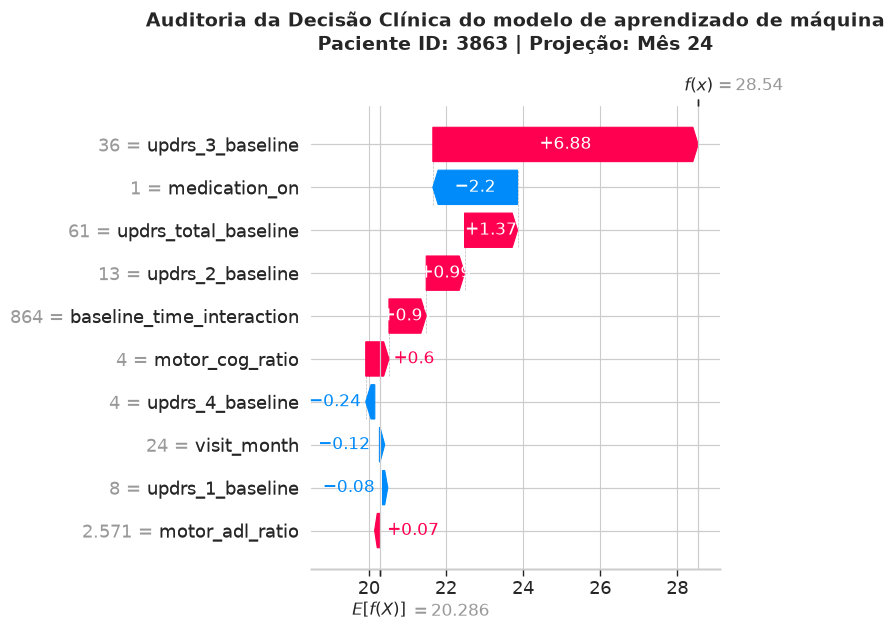

In [80]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


explainer = shap.TreeExplainer(modelo_vencedor)

id_paciente = 3863 # Paciente em que o modelo teve bom desempenho, selecionado manualmente, apenas para fins de apresentação

caso_clinico = df_resultados_finais[
    (df_resultados_finais['patient_id'] == id_paciente) &
    (df_resultados_finais['visit_month'] == 24)
]

X_caso = caso_clinico[features_clinicas]
y_real = caso_clinico[target].values[0]

shap_values = explainer(X_caso)

soma_shap = np.sum(shap_values.values)
valor_esperado = explainer.expected_value
if isinstance(valor_esperado, (list, np.ndarray)):
    valor_esperado = valor_esperado[0]

predicao_modelo = soma_shap + valor_esperado

print(f"-> Paciente Selecionado: ID {id_paciente}")
print(f"-> Nota Real do UPDRS 3 (Medida pelo Médico): {y_real}")
print(f"-> Nota Prevista pelo modelo de aprendizado de máquina: {predicao_modelo:.2f}")
print(f"-> Erro Clínico Absoluto: {abs(y_real - predicao_modelo):.2f} pontos\n")

print("Gerando o Relatório Visual de Auditoria...")
plt.figure(figsize=(10, 6))

shap.plots.waterfall(shap_values[0], max_display=10, show=False)

plt.title(f"Auditoria da Decisão Clínica do modelo de aprendizado de máquina\nPaciente ID: {id_paciente} | Projeção: Mês 24",
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

#### 8.5 Validação Longitudinal
Para além da auditoria estática de um único mês, essa seção tem por objetivo verificar se o modelo preditivo neurodegenerativo possui a capacidade de acompanhar a tendência da doença ao longo dos anos. 

Abaixo, plotamos a trajetória completa do paciente auditado. A linha contínua representa o declínio motor real medido clinicamente pelo neurologista ao longo das consultas. A linha tracejada representa a projeção temporal contínua desenhada pela Inteligência Artificial. Esta sobreposição visual permite à banca avaliar se o algoritmo conseguiu capturar os platôs e as inclinações naturais da fisiologia do paciente, validando a robustez longitudinal do modelo.

Gerando Gráfico de Trajetória Longitudinal...



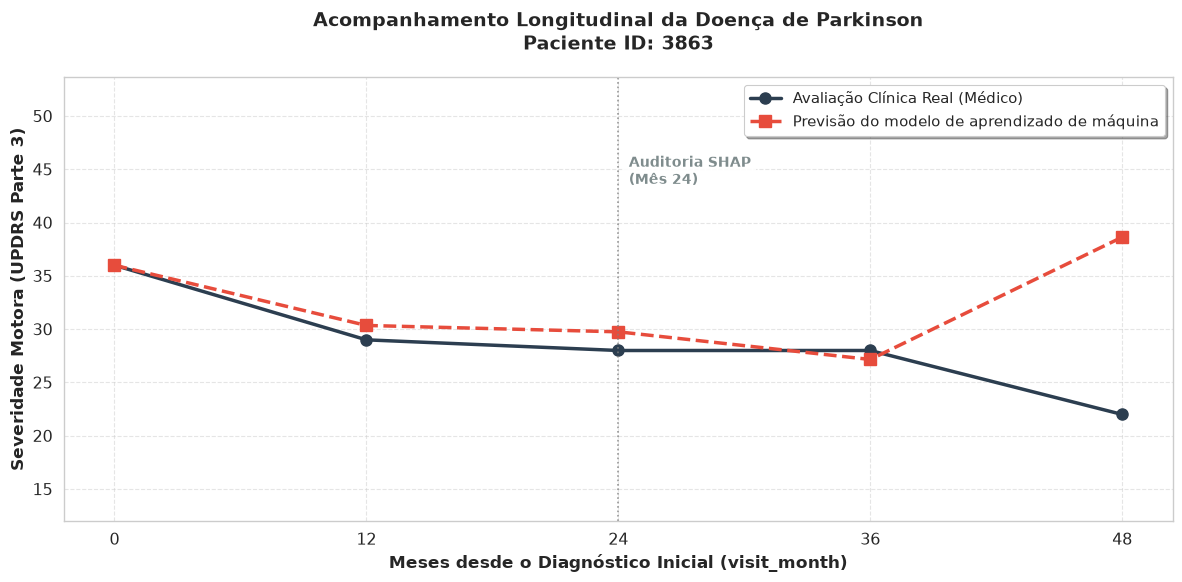

In [81]:
print("Gerando Gráfico de Trajetória Longitudinal...\n")

# ============================================================
# 1. Isolando a Linha do Tempo do Paciente e Injetando o Mês 0
# ============================================================
# O id_paciente é herdado automaticamente da célula anterior de auditoria
historico_paciente = df_resultados_finais[
    df_resultados_finais['patient_id'] == id_paciente
].sort_values(by='visit_month')

# Extraímos a nota do diagnóstico inicial (Mês 0)
u3_baseline = historico_paciente['updrs_3_baseline'].iloc[0]

# Construímos os eixos estendidos para o gráfico, forçando o início no ponto zero
eixo_x = [0] + list(historico_paciente['visit_month'])
eixo_y_real = [u3_baseline] + list(historico_paciente[target])
eixo_y_pred = [u3_baseline] + list(historico_paciente['predicao_modelo_C'])

# ======================================
# 2. Configurando a Estética do Gráfico
# ======================================
plt.figure(figsize=(12, 6))

# Linha da Nota Real (Médico) - Ancorada no Mês 0
plt.plot(eixo_x, eixo_y_real, marker='o', markersize=8, linewidth=2.5,
         color='#2C3E50', label='Avaliação Clínica Real (Médico)')

# Linha da Previsão (Modelo de Aprendizado de Máquina) - Ancorada no Mês 0
plt.plot(eixo_x, eixo_y_pred, marker='s', markersize=8, linewidth=2.5, linestyle='--',
         color='#E74C3C', label='Previsão do modelo de aprendizado de máquina')

# ==========================================
# 3. Destacando o Ponto de Auditoria (Mês 24)
# ==========================================
plt.axvline(x=24, color='gray', linestyle=':', alpha=0.8)

# ==========================================
# 4. Ajustes Finais
# ==========================================
plt.title(f"Acompanhamento Longitudinal da Doença de Parkinson\nPaciente ID: {id_paciente}",
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Meses desde o Diagnóstico Inicial (visit_month)", fontsize=12, fontweight='bold')
plt.ylabel("Severidade Motora (UPDRS Parte 3)", fontsize=12, fontweight='bold')

min_y = min(min(eixo_y_real), min(eixo_y_pred))
max_y = max(max(eixo_y_real), max(eixo_y_pred))
plt.ylim(max(0, min_y - 10), max_y + 15)

# Posicionamento corrigido do texto explicativo para evitar sobreposição
plt.text(24.5, max_y + 5, 'Auditoria SHAP\n(Mês 24)', color='#7F8C8D', fontsize=10,
         fontweight='bold', bbox=dict(facecolor='white', edgecolor='none', alpha=0.9, zorder=5))

# Forçar o eixo X a exibir todos os meses oficiais da linha do tempo, incluindo o 0
plt.xticks(eixo_x)

plt.legend(fontsize=11, loc='upper right', frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
### 9. Conclusões, Limitações e Próximos Passos

O desenvolvimento deste ecossistema preditivo estabelece uma linha de base metodológica para a projeção da severidade motora (escala MDS-UPDRS Parte 3) na Doença de Parkinson, equilibrando capacidade computacional com a necessidade de transparência na medicina.

#### 9.1 Conclusões
1. **Falha em Rejeitar a Hipótese Nula (Avaliação Proteômica vs. Clínica):** A comparação conduzida na *Fase 1* demonstrou que o Modelo A (estritamente clínico, RMSE CV = 9.39) obteve uma performance muito próxima ao Modelo B (clínico acrescido de 100 features proteômicas, RMSE CV = 9.22). A aplicação do Teste Pareado de Wilcoxon sobre os erros absolutos (*Out-of-Fold*) confirmou que a diferença marginal de 0.17 pontos não possui significância estatística ($p \geq 0.05$). Portanto, **falhamos em rejeitar a Hipótese Nula ($H_0$)**. O ganho preditivo nulo não justifica o custo financeiro e o caráter invasivo da coleta molecular para o monitoramento longitudinal contínuo, validando a soberania do exame clínico de consultório.
2. **Impacto da Engenharia de Features:** A expansão dimensional executada na *Fase 2*, baseada em interações de domínio e sem o uso de variáveis de vazamento (como `visit_6m`), provou-se altamente eficiente. A introdução das taxas funcionais (`motor_adl_ratio`, `motor_cog_ratio`) e do vetor de aceleração temporal (`baseline_time_interaction`) reduziu o erro absoluto médio de validação cruzada do Modelo C para **RMSE = 9.11** e o **SMAPE para 46.09%**.
3. **Explicabilidade Prática:** Através dos Valores SHAP, o caráter de "caixa preta" do algoritmo de *Gradient Boosting* (LightGBM) foi mitigado. O mapeamento aditivo de forças permitiu auditar o peso de cada marcador basal no prognóstico, conferindo possivelmente maior segurança para a aceitação da ferramenta na prática clínica.

#### 9.2 Limitações do Modelo Atual
1. **Inabilidade de Extrapolação de Árvores:** Devido à natureza geométrica dos cortes ortogonais dos algoritmos baseados em árvores, o modelo sofre do fenômeno de *Regressão à Média* quando confrontado com escores basais severamente extremos no diagnóstico (ex: UPDRS 3 inicial maior que 50), tendendo a puxar as curvas subsequentes em direção ao centro de massa dos dados de treinamento.
2. **Ausência de Covariáveis Críticas:** O conjunto de dados restrito não contemplou moduladores biológicos fundamentais da progressão neurodegenerativa, tais como a idade do paciente no diagnóstico, o perfil genético (mutações nos genes *LRRK2* ou *GBA*), o histórico de atividade física e a presença de comorbidades metabólicas.

#### 9.3 Direcionamentos Futuros
Para a evolução desta Prova de Conceito (PoC) rumo a um software de real valor científico, os próximos passos exigiriam:
* O acoplamento do LightGBM a uma camada linear superior (como modelos de efeitos mistos) para corrigir as caudas de extrapolação.
* A condução de uma **Validação Externa** utilizando dados de coortes globais independentes (como o consórcio PPMI) para garantir a generalização do algoritmo.